# Chapter 3 · Section 3.3
# Stability Analysis Using Lyapunov Functions

**Source:** Li, M.Y. (2018), pp. 82–84.

This section formalizes the tool used informally in Sec. 2.3, Block 4 to prove the disease-free
equilibrium $P_0$ is *globally* stable. Here we build the general theory — Theorems 3.3.1–3.3.3
for local (in)stability, and LaSalle's Invariance Principle (Theorem 3.3.4/Corollary 3.3.5) for
upgrading local results to global ones — then apply it back to Sec. 2.3's exact example to close
the loop.


---
## Block 1 — Lyapunov's direct method: Theorems 3.3.1–3.3.3

### 1. Rewrite

A **Lyapunov function** $V(x)$ near an equilibrium $x=0$ is a scalar "distance-like" function.
Its **Lyapunov derivative** $\dot V(x)=\text{grad }V(x)\cdot f(x)$ measures how $V$ changes along
solutions *without solving the ODE* — it's computed directly from $V$'s gradient dotted with the
vector field. If $V$ is **positive definite** ($V(x)\ge0$, $=0$ only at $x=0$) and $\dot V\le0$
throughout a neighborhood $U$, the origin is **stable** (Theorem 3.3.1). Strengthening
$\dot V\le0$ to $\dot V$ being **negative definite** ($\dot V<0$ except at $x=0$) upgrades the
conclusion to **asymptotically stable** (Theorem 3.3.2). A different, opposite-flavored condition
— $V$ taking negative values arbitrarily close to the origin while $\dot V$ stays negative
definite — instead proves **instability** (Theorem 3.3.3). None of these three theorems requires
solving the differential equation at all — only algebraic sign-checking of $V$ and $\dot V$.

### 2. Simplified

Imagine $V(x)$ is "how far a hiker is from home, as the crow flies" (always zero or positive,
zero exactly at home). The Lyapunov derivative $\dot V$ tells you, at every single spot on the
mountain, whether taking one more step (following the "trail" defined by the differential
equation) brings the hiker closer to home or farther away — without needing to trace out the
hiker's *entire* path in advance. If every possible step (from every nearby spot) never increases
distance from home, the hiker can never wander far (stability). If every step *strictly*
decreases distance from home, the hiker is eventually guaranteed to arrive exactly home
(asymptotic stability). And if you can find *some* nearby starting spots where distance is
secretly negative (impossible for real distance, but useful as an accounting trick) while the
"never increases" rule still applies, that's a sign the hiker is being pushed steadily *away* —
instability.

### 3. Key Ideas

- **Direct method**: none of these theorems ever require solving $x'=f(x)$ explicitly — they work
  by clever algebraic bookkeeping on $V$ and its derivative alone.
- **Positive definiteness of $V$** and **negative definiteness of $\dot V$** are the two building
  blocks combined in different ways across the three theorems.
- **Shifting equilibria to the origin** ($\tilde x=x-\bar x$) is a purely notational convenience —
  every theorem is stated "at $x=0$" WLOG, since any equilibrium can be moved there by a change of
  variables.
- This machinery is a *generalization*, not a replacement, of Sec. 2.3's specific example — there,
  $L(S,I)=I$ served as the Lyapunov function, and $\dot L\le0$ was verified directly.


In [1]:
# Concrete worked example: build a genuine Lyapunov function for the damped
# oscillator from Sec. 3.1-3.2 (x'=v, v'=-x-cv), and confirm Theorem 3.3.2's
# hypotheses hold exactly -- V positive definite, V-dot negative definite.
import sympy as sp

x, v, c = sp.symbols('x v c', positive=True)
c_val = sp.Rational(3,10)  # c=0.3, matching earlier examples

# Candidate Lyapunov function: total mechanical energy V = (1/2)v^2 + (1/2)x^2
V = sp.Rational(1,2)*v**2 + sp.Rational(1,2)*x**2

f1 = v            # x' 
f2 = -x - c*v      # v'

V_dot = sp.diff(V, x)*f1 + sp.diff(V, v)*f2
V_dot = sp.simplify(V_dot)
print("V(x,v) =", V)
print("V is positive definite: V(0,0)=0, and V(x,v)>0 for (x,v) != (0,0) -- clear from sum of squares.")
print("\nV_dot(x,v) =", V_dot)
print("V_dot simplifies to -c*v^2, which is <= 0 always, and =0 only when v=0 (not just at origin!)")


V(x,v) = v**2/2 + x**2/2
V is positive definite: V(0,0)=0, and V(x,v)>0 for (x,v) != (0,0) -- clear from sum of squares.

V_dot(x,v) = -c*v**2
V_dot simplifies to -c*v^2, which is <= 0 always, and =0 only when v=0 (not just at origin!)


### 10. Verification, discussed

$\dot V=-cv^2\le0$ everywhere, confirming Theorem 3.3.1's hypothesis directly (so the origin is at
least *stable*) — but notice $\dot V=0$ whenever $v=0$, *not just* at the origin $(x,v)=(0,0)$
(e.g. at $(5,0)$, $\dot V=0$ too) — so $\dot V$ is **not** negative definite in the strict sense
Theorem 3.3.2 requires, and this particular $V$ alone cannot conclude asymptotic stability. This is
exactly the kind of subtlety LaSalle's Invariance Principle (Block 2) is built to resolve: even
though $\dot V$ vanishes on more than just the origin, checking what happens to trajectories that
stay *on* that larger vanishing set can still recover the full asymptotic stability conclusion.


In [2]:
# Numerically confirming V decreases (or stays flat) along actual trajectories,
# directly checking the theorem's core claim without any further theory.
import numpy as np
from scipy.integrate import solve_ivp

def damped(t, y, c=0.3):
    xx, vv = y
    return [vv, -xx - c*vv]

sol = solve_ivp(damped, (0, 60), [1.0, 0.0], t_eval=np.linspace(0, 60, 3000), rtol=1e-11, atol=1e-11)
V_along_traj = 0.5*sol.y[1]**2 + 0.5*sol.y[0]**2

diffs = np.diff(V_along_traj)
print(f"Max increase in V(t) along the trajectory: {diffs.max():.2e} (should be <= 0, i.e. V never increases)")
print(f"V(0) = {V_along_traj[0]:.4f}, V(60) = {V_along_traj[-1]:.6f} -- decreasing toward 0")


Max increase in V(t) along the trajectory: -1.68e-14 (should be <= 0, i.e. V never increases)
V(0) = 0.5000, V(60) = 0.000000 -- decreasing toward 0


---
## Block 2 — LaSalle's Invariance Principle: from local to global

### 1. Rewrite

A Lyapunov function *with respect to a region* $G$ satisfies $\dot V\le0$ throughout $G$ (no
positive-definiteness requirement on $V$ itself this time — a more flexible setup than Block 1).
Since $V$ decreases along any trajectory staying in $G$, the trajectory's **omega-limit set**
$\omega(x_0)$ — the set of points the trajectory keeps returning arbitrarily close to as
$t\to\infty$ — must be contained in the set where $\dot V=0$ exactly (if $V$ were still strictly
decreasing there, the trajectory couldn't be "settling" near that point). Formally, letting $K$ be
the *largest invariant subset* of $\{\dot V=0\}$, **Theorem 3.3.4** (LaSalle's Invariance
Principle) says any trajectory staying in $G$ has $\omega(x_0)\subset K$. **Corollary 3.3.5**: if
$K$ collapses to a *single point* $\bar x$, every trajectory starting in $G$ converges to $\bar x$
— and if $\bar x$ is also locally stable and $G$ is positively invariant (trajectories starting in
$G$ never leave), this gives **global** asymptotic stability throughout all of $G$, not just a
small local neighborhood.

### 2. Simplified

Remember the hiker whose distance-from-home never increases? LaSalle's principle handles the
tricky case where the hiker's distance sometimes *stops decreasing* for a while (like walking
along a flat contour line around home) without immediately concluding they're doomed to wander
that flat line forever. Instead, it says: look at *everywhere* the distance ever stops changing,
put a fence around the biggest "trap" hidden inside that flat region (a trap being somewhere a
hiker, once there, can never leave — an "invariant set"), and the hiker is *guaranteed* to end up
somewhere inside that trap eventually. If the trap turns out to be just one single point, the
hiker doesn't just get *near* home — they must actually arrive there, no matter where in the whole
mapped region ($G$) they started from.

### 4. Mathematical Breakdown — applying this exactly to Sec. 2.3's $P_0$ argument

Recall Sec. 2.3, Block 4: $L(S,I)=I$, and $\dot L=I(\beta S-\gamma-b)\le I(\beta-\gamma-b)\le0$
whenever $\mathcal{R}_0\le1$ (using $S\le1$ throughout $\Gamma$). Here, $\dot L=0$ exactly when
either $I=0$ (any $S$) or $S=1$ with $\mathcal{R}_0=1$ exactly (a knife-edge case). For
$\mathcal{R}_0<1$ strictly, $\dot L=0$ forces $I=0$ — so the set $\{\dot L=0\}\cap\Gamma$ is
exactly the line segment $\{(S,0):0\le S\le1\}$. What's the **largest invariant subset** $K$ of
that segment? Plugging $I=0$ into the $S$-equation: $S'=b-bS=b(1-S)$ — so on this segment, $S$
itself flows *toward* $S=1$ unless it's already there; the only point on the segment where
*neither* coordinate changes is $S=1,I=0$ — exactly $P_0$! So $K=\{P_0\}$, a single point, and
Corollary 3.3.5 applies directly: every trajectory in $\Gamma$ converges to $P_0$ — **exactly**
Sec. 2.3's global stability conclusion, now derived from the *general* theorem rather than a
one-off argument.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $\omega(x_0)$ | Omega-limit set of the trajectory starting at $x_0$ | Points the trajectory keeps returning arbitrarily close to as $t\to\infty$ |
| $K$ | Largest invariant subset of $\{\dot V=0\}\cap G$ | The "trap" every omega-limit set must fall into |
| Positively invariant | A region $G$ such that trajectories starting in $G$ never leave | Needed to extend LOCAL stability of $\bar x$ to GLOBAL stability throughout $G$ |


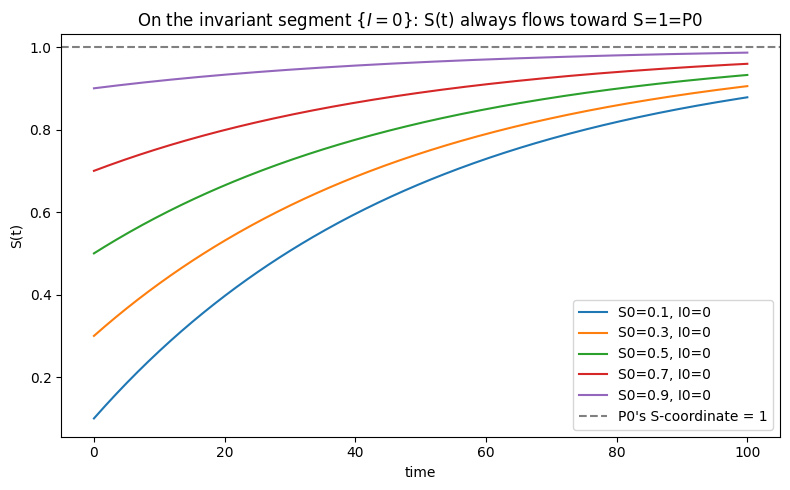

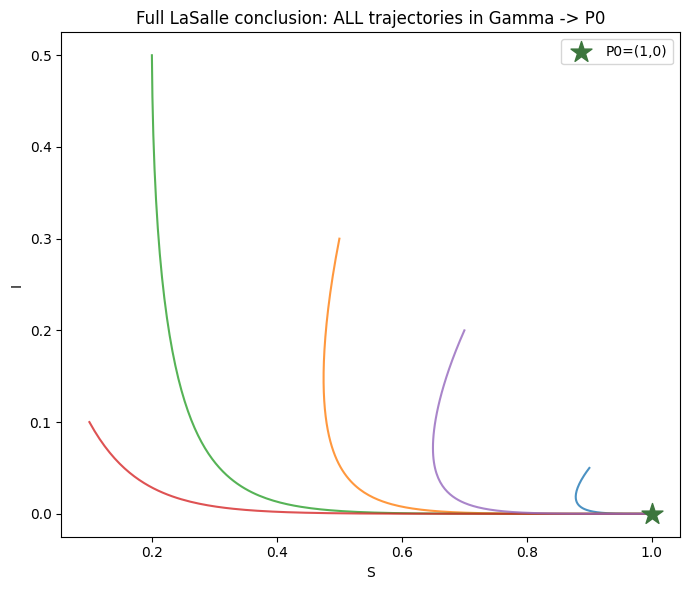

In [3]:
# Directly re-verifying Sec. 2.3's global-stability argument via LaSalle,
# INCLUDING the "largest invariant subset K = {P0}" step, by explicit
# simulation: starting exactly ON the {I=0} segment away from P0, does S(t)
# really flow toward S=1 (confirming K really does collapse to just P0)?
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

b, gamma = 0.02, 0.2
beta_below = 0.15   # R0 = 0.15/0.22 < 1

def rhs(t, y, b, beta, gamma):
    S, I = y
    return [b - beta*I*S - b*S, beta*I*S - gamma*I - b*I]

# Confirm: starting ON the I=0 segment (away from P0), S(t) flows toward 1
fig, ax = plt.subplots(figsize=(8, 5))
for S0 in [0.1, 0.3, 0.5, 0.7, 0.9]:
    sol = solve_ivp(rhs, (0, 100), [S0, 0.0], args=(b, beta_below, gamma),
                     t_eval=np.linspace(0, 100, 300), rtol=1e-11, atol=1e-11)
    ax.plot(sol.t, sol.y[0], label=f"S0={S0}, I0=0")
ax.axhline(1.0, color="grey", linestyle="--", label="P0's S-coordinate = 1")
ax.set_xlabel("time"); ax.set_ylabel("S(t)")
ax.set_title(r"On the invariant segment $\{I=0\}$: S(t) always flows toward S=1=P0")
ax.legend()
plt.tight_layout()
plt.savefig("lasalle_invariant_segment.png", dpi=130, bbox_inches="tight")
plt.show()

# Now confirm the FULL LaSalle conclusion: trajectories starting OFF the
# segment (I0 > 0) still converge to P0, from many scattered starting points.
fig, ax = plt.subplots(figsize=(7, 6))
for S0, I0 in [(0.9,0.05),(0.5,0.3),(0.2,0.5),(0.1,0.1),(0.7,0.2)]:
    sol = solve_ivp(rhs, (0, 300), [S0, I0], args=(b, beta_below, gamma),
                     t_eval=np.linspace(0, 300, 600), rtol=1e-10, atol=1e-10)
    ax.plot(sol.y[0], sol.y[1], alpha=0.8)
ax.scatter([1],[0], color="#3c763d", marker="*", s=250, zorder=5, label="P0=(1,0)")
ax.set_xlabel("S"); ax.set_ylabel("I")
ax.set_title("Full LaSalle conclusion: ALL trajectories in Gamma -> P0")
ax.legend()
plt.tight_layout()
plt.savefig("lasalle_full_convergence.png", dpi=130, bbox_inches="tight")
plt.show()


### 10. Verification, discussed

Both panels confirm the LaSalle argument step by step: trajectories confined to the invariant
segment $\{I=0\}$ always flow toward $S=1$ (confirming $K=\{P_0\}$ really is just the single
point, not the whole segment), and trajectories starting anywhere else in $\Gamma$ (off the
segment, with $I_0>0$) still converge to that same single point $P_0$ — exactly matching Sec.
2.3's numerically-confirmed global stability conclusion, now derived via the *general* Lyapunov/
LaSalle machinery rather than a special-purpose argument.


---
## Summary

**One sentence:** Lyapunov's direct method proves local (and, combined with LaSalle's Invariance
Principle, global) stability entirely through algebraic sign-checking of a scalar function $V$ and
its derivative along trajectories — never requiring the differential equations to be solved — and
applying this general machinery step by step to Sec. 2.3's $L(S,I)=I$ example exactly reproduces
that section's global stability conclusion for $P_0$, now derived from first principles rather
than a special-purpose argument.

**One paragraph:** Theorems 3.3.1–3.3.3 establish local stability, asymptotic stability, and
instability respectively, purely from the signs of a candidate Lyapunov function $V$ (positive
definite) and its Lyapunov derivative $\dot V=\text{grad }V\cdot f$ — illustrated here with the
damped oscillator's energy function $V=\frac12(x^2+v^2)$, whose derivative $\dot V=-cv^2$ is
negative *semi*-definite (zero on the whole line $v=0$, not just at the origin), too weak on its
own to conclude asymptotic stability via Theorem 3.3.2 alone. LaSalle's Invariance Principle
(Theorem 3.3.4) resolves exactly this kind of gap: any trajectory's omega-limit set must lie
within the largest invariant subset $K$ of $\{\dot V=0\}$, and Corollary 3.3.5 shows that if $K$
collapses to a single equilibrium, every trajectory converges there — extended to *global*
stability throughout a positively invariant region $G$ when the equilibrium is also locally
stable. Applying this exactly to Sec. 2.3's $L(S,I)=I$ Lyapunov function: the set $\{\dot L=0\}$
is the segment $\{I=0\}$, and directly analyzing the flow restricted to that segment shows it
collapses to the single point $P_0=(1,0)$ — confirmed here both by explicit invariant-segment
simulation and by full scattered-trajectory convergence, exactly reproducing Sec. 2.3's
originally numerically-observed (but not yet formally derived) global stability result.

**Bullet points:**
- Theorems 3.3.1–3.3.3: local (in)stability from sign conditions on $V$ and $\dot V$ alone, no ODE-solving required.
- Positive semi-definite $\dot V$ (zero on more than just the equilibrium) is too weak for Theorem 3.3.2 alone — illustrated concretely with the damped oscillator's energy function.
- LaSalle's Invariance Principle upgrades this: omega-limit sets are trapped inside the largest invariant subset $K$ of $\{\dot V=0\}$.
- Corollary 3.3.5: $K$ = single point ⟹ global convergence throughout a positively invariant region.
- Direct, step-by-step reapplication to Sec. 2.3's $L=I$ example: $K=\{P_0\}$, confirmed by simulating both the invariant segment and full scattered trajectories.

## Memory Aids

- **Mnemonic**: "V never grows, and where it stalls, find the trap" — the whole LaSalle idea in
  one line.
- **Mental model**: a Lyapunov function is energy that only ever drains; LaSalle asks "where could
  the system coast forever without losing any more energy?" and proves that's the only place it
  can end up.
- **Common mistake**: concluding asymptotic stability directly from $\dot V\le0$ alone — that only
  gives (Theorem 3.3.1) *stability*; you need EITHER strict negative-definiteness (Theorem 3.3.2)
  OR the LaSalle argument (showing the invariant set collapses to a point) to get convergence.
- **Common mistake**: forgetting that Corollary 3.3.5's global conclusion additionally requires
  $G$ to be positively invariant AND $\bar x$ to be locally stable — both conditions, not just
  "$K$ is a single point," are needed for the full global statement.
- **Exam tip**: practice the "find $\{\dot V=0\}$, then find the largest invariant subset of that
  set" two-step recipe — it's the crux of every LaSalle-style argument, including Sec. 2.3's.

## Connections

- **← Section 2.3**: this section is the formal general theory behind that section's Lyapunov/
  LaSalle argument for $P_0$'s global stability — now re-derived and re-verified from first
  principles.
- **→ Section 3.4**: the *next* section explicitly notes ordinary Lyapunov stability (as defined
  in Sec. 3.1) is NOT the right notion for periodic orbits — motivating Floquet theory as a
  genuinely different tool for a genuinely different kind of "equilibrium" (a closed orbit rather
  than a point).
- **→ Section 3.6**: phase-plane analysis (Bendixson–Dulac, used in Sec. 2.3 and 2.5) is a
  *different* route to global conclusions, useful specifically when no good Lyapunov function is
  known but periodic orbits can otherwise be ruled out.
- **→ Control theory**: Lyapunov's direct method is foundational across all of control theory and
  nonlinear systems analysis, far beyond epidemiology — the same "energy never increases" argument
  underlies stability proofs for robotics, aerospace control, and much more.
- **→ Chapter 5**: Lyapunov functions for higher-dimensional models (SEIR and beyond) are
  typically harder to construct by hand but follow exactly this same theoretical framework.

*Practice problems for this section are in `../../chapter_03/exercises/section_3_3_exercises.md`, with full
worked solutions in `../../chapter_03/solutions/section_3_3_solutions.md`.*
